In [2]:
# 运行此代码单元格来挂载 Google Drive
from google.colab import drive
drive.mount('/content/drive')

import os

# 成功后 Google Drive内容将可以在以下路径访问：
# '/content/drive/My Drive/'
# 假如文件夹名为 'my_project_data' 并且存储在Google Drive的根目录下
# 在Colab中就可以通过 '/content/drive/My Drive/my_project_data/' 来访问它。
drive_path = '/content/drive/My Drive' # 定义想要切换到的文件夹路径

if os.path.exists(drive_path):
    os.chdir(drive_path)
    print(f"当前工作目录已切换至: {os.getcwd()}")
else:
    print(f"错误: 路径不存在 {drive_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
当前工作目录已切换至: /content/drive/My Drive


## 1) 设定环境并读取基本信息
解析 `dataset_info.json` 以动态获取数据特征（通道数、采样点、类别等），消除硬编码。

In [9]:
import json
import h5py
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import os
import copy
from torch.utils.data import DataLoader

# 假设自定义的 Dataset 路径已正确配置
from course_project.TEST_DATASET import TrainDataset, TestDataset

DATA_NAME = "SLEEP"
DATA_INFO_PATH = f"course_project/{DATA_NAME}/dataset_info.json"
INDEX_PATH_TRAIN = f"course_project/{DATA_NAME}/train.h5"
INDEX_PATH_VAL = f"course_project/{DATA_NAME}/val.h5"
INDEX_PATH_TEST = f"course_project/{DATA_NAME}/test_x_only.h5"

with open(DATA_INFO_PATH, "r", encoding="utf-8") as f:
    info = json.load(f)

num_labels = info["dataset"]["num_labels"]
category_list = info["dataset"]["category_list"]
channels = info["dataset"]["channels"]
target_sampling_rate = info["processing"]["target_sampling_rate"]
window_sec = info["processing"]["window_sec"]

print("=== Dataset Information ===")
print("Number of Labels:", num_labels)
print("Categories:", category_list)
print("Channels (count):", len(channels))
print("Target Sampling Rate (Hz):", target_sampling_rate)
print("Window Size (sec):", window_sec)

# 动态确定输入特征维度
time_points = int(target_sampling_rate * window_sec)
num_channels = len(channels)
num_classes = num_labels

=== Dataset Information ===
Number of Labels: 5
Categories: ['Wake', 'N1', 'N2', 'N3', 'REM']
Channels (count): 6
Target Sampling Rate (Hz): 200.0
Window Size (sec): 30.0


## 2) 检查数据形状

In [10]:
print("========== 检查训练集 (Train) ==========")
with h5py.File(INDEX_PATH_TRAIN, "r") as f:
    print("keys:", list(f.keys()))
    print("x dtype:", f["X"].dtype)
    print("x shape:", f["X"].shape)
    print("y dtype:", f["y"].dtype)
    print("y shape:", f["y"].shape)
    y = f["y"][()]
    print("unique:", np.unique(y))

print("\n========== 检查验证集 (Validation) ==========")
with h5py.File(INDEX_PATH_VAL, "r") as f:
    print("keys:", list(f.keys()))
    print("x dtype:", f["X"].dtype)
    print("x shape:", f["X"].shape)
    print("y dtype:", f["y"].dtype)
    print("y shape:", f["y"].shape)
    y = f["y"][()]
    print("unique:", np.unique(y))

print("\n========== 检查测试集 (Test - X only) ==========")
with h5py.File(INDEX_PATH_TEST, "r") as f:
    print("keys:", list(f.keys()))
    print("x dtype:", f["X"].dtype)
    print("x shape:", f["X"].shape)

========== 检查训练集 (Train) ==========
keys: ['X', 'y']
x dtype: float32
x shape: (3921, 6, 6000)
y dtype: int64
y shape: (3921,)
unique: [0 1 2 3 4]

========== 检查验证集 (Validation) ==========
keys: ['X', 'y']
x dtype: float32
x shape: (1941, 6, 6000)
y dtype: int64
y shape: (1941,)
unique: [0 1 2 3 4]

========== 检查测试集 (Test - X only) ==========
keys: ['X']
x dtype: float32
x shape: (1945, 6, 6000)


## 3) 定义模型
最终模型：**S3Net**

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ConvBlock(nn.Module):
    def __init__(self, in_channels, feat_out, stride=(1, 1)):
        super(ConvBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, feat_out, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.InstanceNorm2d(feat_out, affine=True)
        self.relu1 = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(feat_out, feat_out, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.InstanceNorm2d(feat_out, affine=True)
        self.relu2 = nn.ReLU(inplace=True)

        self.shortcut_conv = nn.Conv2d(in_channels, feat_out, kernel_size=1, stride=stride, bias=False)
        self.shortcut_bn = nn.InstanceNorm2d(feat_out, affine=True)
        self.final_relu = nn.ReLU(inplace=True)

    def forward(self, x):
        out = self.relu1(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        shortcut = self.shortcut_bn(self.shortcut_conv(x))
        return self.final_relu(out + shortcut)

class IdentityBlock(nn.Module):
    def __init__(self, in_channels, feat_out):
        super(IdentityBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, feat_out, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.InstanceNorm2d(feat_out, affine=True)
        self.relu1 = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(feat_out, feat_out, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.InstanceNorm2d(feat_out, affine=True)
        self.final_relu = nn.ReLU(inplace=True)

    def forward(self, x):
        out = self.relu1(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return self.final_relu(out + x)

class TimeAlignment(nn.Module):
    def __init__(self, output_dim):
        super(TimeAlignment, self).__init__()
        self.pool = nn.AdaptiveAvgPool2d((1, output_dim))

    def forward(self, x):
        # x shape: (B, C, F, T), 压缩频域维度至1，并对齐时间步
        out = self.pool(x)
        return out.squeeze(2) # 返回 (B, C, output_dim)

class ResidualBlock(nn.Module):
    def __init__(self, in_channels):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, 64, kernel_size=(7, 7), stride=(2, 2), padding=3, bias=False)
        self.bn_conv1 = nn.InstanceNorm2d(64, affine=True)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.conv_block2 = ConvBlock(64, 64, stride=(1, 1))
        self.identity_block2 = IdentityBlock(64, 64)

        self.conv_block3 = ConvBlock(64, 128, stride=(2, 2))
        self.identity_block3 = IdentityBlock(128, 128)

        self.conv_block4 = ConvBlock(128, 256, stride=(2, 2))
        self.identity_block4 = IdentityBlock(256, 256)

        self.cross_alignment1 = TimeAlignment(output_dim=1000)
        self.cross_alignment2 = TimeAlignment(output_dim=500)
        self.cross_alignment3 = TimeAlignment(output_dim=250)

    def forward(self, input_tensor):
        x = self.maxpool(self.relu(self.bn_conv1(self.conv1(input_tensor))))

        x = self.identity_block2(self.conv_block2(x))
        cross_x1 = self.cross_alignment1(x)

        x = self.identity_block3(self.conv_block3(x))
        cross_x2 = self.cross_alignment2(x)

        x = self.identity_block4(self.conv_block4(x))
        cross_x3 = self.cross_alignment3(x)

        return cross_x1, cross_x2, cross_x3

class PatchEmbed(nn.Module):
    def __init__(self, img_size=6000, patch_size=50, in_chans=6, embed_dim=64, stride=25):
        super().__init__()
        self.proj = nn.Conv1d(in_chans, embed_dim, kernel_size=patch_size, stride=stride)
        self.num_patches = (img_size - patch_size) // stride + 1

    def forward(self, x):
        return self.proj(x)

class CrossAttentionLayer(nn.Module):
    def __init__(self, dim, context_dim, num_heads=8):
        super().__init__()
        self.num_heads = num_heads
        self.scale = (dim // num_heads) ** -0.5

        # 补全 Transformer 的 LayerNorm (Pre-Norm架构)
        self.norm_x = nn.LayerNorm(dim)
        self.norm_c = nn.LayerNorm(context_dim)

        self.q_proj = nn.Linear(dim, dim)
        self.k_proj = nn.Linear(context_dim, dim)
        self.v_proj = nn.Linear(context_dim, dim)
        self.out_proj = nn.Linear(dim, dim)

    def forward(self, x, context):
        x = x.permute(0, 2, 1)
        context = context.permute(0, 2, 1)

        x_norm = self.norm_x(x)
        c_norm = self.norm_c(context)

        B, L, C = x_norm.shape
        _, L_c, _ = c_norm.shape

        q = self.q_proj(x_norm).view(B, L, self.num_heads, -1).permute(0, 2, 1, 3)
        k = self.k_proj(c_norm).view(B, L_c, self.num_heads, -1).permute(0, 2, 1, 3)
        v = self.v_proj(c_norm).view(B, L_c, self.num_heads, -1).permute(0, 2, 1, 3)

        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        out = (attn @ v).transpose(1, 2).reshape(B, L, C)

        x = x + self.out_proj(out)
        return x.permute(0, 2, 1)

class GatingNetwork(nn.Module):
    def __init__(self, stft_dim=256, seq_dim=256, num_experts=2):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(stft_dim + seq_dim, 128),
            nn.LayerNorm(128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.1),
            nn.Linear(128, num_experts)
        )

    def forward(self, stft_feat, seq_feat):
        stft_pool = stft_feat.mean(dim=-1)
        seq_pool = seq_feat.mean(dim=-1)
        logits = self.fc(torch.cat([stft_pool, seq_pool], dim=-1))

        # 引入温度系数 / 2.0，软化权重分布，防止测试集上因为微小的 Logit 偏差，导致某个专家权重绝对为 0
        weights = F.softmax(logits / 2.0, dim=-1)

        return weights, logits

class ExpertNetwork(nn.Module):
    def __init__(self, seq_dim=256, stft_dim=256, num_classes=3):
        super().__init__()
        self.fc = nn.Sequential(
            # 网络入口增加 LayerNorm，锁死进入全连接层的特征尺度
            nn.LayerNorm(seq_dim + stft_dim),
            nn.Linear(seq_dim + stft_dim, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, seq_feat, stft_feat):
        seq_pool = seq_feat.mean(dim=-1)
        stft_pool = stft_feat.mean(dim=-1)
        return self.fc(torch.cat([seq_pool, stft_pool], dim=-1))

class S3Net(nn.Module):
    """ S3Net 核心网络实现 """
    def __init__(self, num_classes=5, in_chans=6, embed_dim=64):
        super().__init__()
        self.patch_embed = PatchEmbed(img_size=6000, patch_size=50, in_chans=in_chans, embed_dim=embed_dim, stride=25)
        self.pos_drop = nn.Dropout(p=0.1)

        num_patches = self.patch_embed.num_patches
        self.pos_embed = nn.Parameter(torch.zeros(1, embed_dim, num_patches))

        self.res_block = ResidualBlock(in_channels=in_chans)

        self.shared_layer0 = CrossAttentionLayer(dim=embed_dim, context_dim=64)
        self.shared_layer1 = CrossAttentionLayer(dim=embed_dim, context_dim=128)

        self.feature_proj = nn.Conv1d(embed_dim, 256, kernel_size=1)

        self.gating_network = GatingNetwork(stft_dim=256, seq_dim=256, num_experts=2)

        self.hard_separated_expert = ExpertNetwork(seq_dim=256, stft_dim=256, num_classes=3)
        self.easy_separated_expert = ExpertNetwork(seq_dim=256, stft_dim=256, num_classes=2)

    def forward(self, x, stft):
        stft = stft.permute(0, 3, 1, 2)
        stft1, stft2, stft3 = self.res_block(stft)

        x = self.pos_drop(self.patch_embed(x) + self.pos_embed)

        x = self.shared_layer0(x.contiguous(), stft1)
        x = self.shared_layer1(x.contiguous(), stft2)
        x = self.feature_proj(x)

        gate_weights, gate_logits = self.gating_network(stft3, x)

        logits_transition = self.hard_separated_expert(x, stft3)
        logits_stable = self.easy_separated_expert(x, stft3)

        weighted_logits_transition = logits_transition * gate_weights[:, 0].unsqueeze(1)
        weighted_logits_stable = logits_stable * gate_weights[:, 1].unsqueeze(1)

        final_logits = torch.cat([weighted_logits_transition, weighted_logits_stable], dim=1)

        if self.training:
            return final_logits, gate_logits
        return final_logits

class SleepStagingModel(nn.Module):
    """ 兼容 DataLoader 的 S3Net 外壳，内置动态 STFT 转换 """
    def __init__(self, input_channels, num_classes, time_points=6000):
        super(SleepStagingModel, self).__init__()
        self.n_fft = 256
        self.hop_length = 64
        self.s3net = S3Net(num_classes=num_classes, in_chans=input_channels, embed_dim=64)

    def forward(self, x):
        B, C, T = x.size()
        x_reshaped = x.view(-1, T)

        window = torch.hann_window(self.n_fft, device=x.device)
        stft_out = torch.stft(
            x_reshaped,
            n_fft=self.n_fft,
            hop_length=self.hop_length,
            window=window,
            return_complex=True
        ).abs()

        _, F_bins, T_frames = stft_out.size()
        stft_out = stft_out.view(B, C, F_bins, T_frames)

        stft_out = stft_out.permute(0, 2, 3, 1)

        return self.s3net(x, stft_out)

## 4) 配置数据加载器、设备与优化器
设备自适应检测（CUDA GPU / Apple MPS / CPU）

In [12]:
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR

# -------------------------
# 超参数设定
# -------------------------
BATCH_SIZE = 64
EPOCHS = 100          # 增加总 Epoch 数，依靠早停来控制结束
LR = 3e-4
WEIGHT_DECAY = 1e-2      # 正则化系数
WARMUP_EPOCHS = 6        # 增加预热 Epoch 数量
PATIENCE = 20        # 早停的耐心值（验证集持续多少轮不上升则停止）

# -------------------------
# 设定计算设备 (GPU / MPS / CPU)
# -------------------------
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

# -------------------------
# 准备 DataLoader
# -------------------------
train_ds = TrainDataset(INDEX_PATH_TRAIN)
val_ds = TrainDataset(INDEX_PATH_VAL)
test_ds = TestDataset(INDEX_PATH_TEST)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False)

# -------------------------
# 实例化模型、损失函数、优化器
# -------------------------
model = SleepStagingModel(
    input_channels=num_channels,  # 自动读取并传入 6
    num_classes=num_classes,      # 自动读取并传入 5
    time_points=time_points       # 自动读取并传入 6000
).to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# 引入 AdamW 及学习率调度器
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
warmup_scheduler = LinearLR(optimizer, start_factor=0.1, end_factor=1.0, total_iters=WARMUP_EPOCHS)
cosine_scheduler = CosineAnnealingLR(optimizer, T_max=max(1, EPOCHS - WARMUP_EPOCHS), eta_min=1e-6)


Using device: cuda


## 5) 模型训练与验证
实现了 **Early Stopping** 和 **Best Model 保存机制**。避免模型训练到最后已经严重过拟合。

In [13]:
# 用于记录曲线的数组
train_losses, val_losses, train_accuracies, val_accuracies = [], [], [], []

best_val_acc = 0.0
best_model_weights = None
epochs_no_improve = 0
has_saved_model = False
best_model_path = None

os.makedirs("model_checkpoints", exist_ok=True)

for epoch in range(EPOCHS):
    # ===== Train =====
    model.train()
    train_loss_sum = 0.0
    train_correct = 0
    train_num = 0

    for data, label in train_loader:
        data, label = data.to(device), label.to(device)
        optimizer.zero_grad()

        # 由于处于 training 模式，S3Net 会返回主 logits 和 gate_logits
        output, gate_logits = model(data)

        # 1. 基础分类损失
        classification_loss = criterion(output, label)

        # 2. 门控损失：将 0,1,2 视作类别 0 (过渡期)，3,4 视作类别 1 (深睡/REM 易分期)
        expert_targets = (label >= 3).long()
        gate_loss = nn.CrossEntropyLoss()(gate_logits, expert_targets)

        # 总 Loss
        loss = classification_loss + gate_loss * 1.0 # alpha = 1.0

        loss.backward()
        # 加入梯度裁剪（防止 Attention 梯度爆炸）
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        batch_size = label.size(0)
        train_loss_sum += loss.item() * batch_size
        train_num += batch_size

        train_pred = torch.argmax(output, dim=1)
        train_correct += (train_pred == label).sum().item()

    epoch_train_loss = train_loss_sum / train_num
    epoch_train_acc = train_correct / train_num

    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)

    # ===== Validation =====
    model.eval()
    val_loss_sum = 0.0
    val_correct = 0
    val_num = 0

    with torch.no_grad():
        for val_data, val_label in val_loader:
            val_data, val_label = val_data.to(device), val_label.to(device)

            val_output = model(val_data)
            val_loss = criterion(val_output, val_label)

            batch_size = val_label.size(0)
            val_loss_sum += val_loss.item() * batch_size
            val_num += batch_size

            val_pred = torch.argmax(val_output, dim=1)
            val_correct += (val_pred == val_label).sum().item()

    epoch_val_loss = val_loss_sum / val_num
    epoch_val_acc = val_correct / val_num

    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    # 执行调度器更新
    if epoch < WARMUP_EPOCHS:
        warmup_scheduler.step()
    else:
        cosine_scheduler.step()

    current_lr = optimizer.param_groups[0]['lr']

    # 打印每轮训练结果 (附带当前学习率方便观察)
    print(
        f"Epoch [{epoch+1:02d}/{EPOCHS}] | "
        f"LR: {current_lr:.6f} | "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Train Acc: {epoch_train_acc:.2%} | "
        f"Val Loss: {epoch_val_loss:.4f} | "
        f"Val Acc: {epoch_val_acc:.2%}"
    )


    # ===== 早停与最佳模型保存逻辑 =====
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        epochs_no_improve = 0  # 只要准确率刷新就重置耐心值

        # 从第 10 个 epoch 开始，并且超越了历史最佳才实际保存模型
        if epoch + 1 >= 10 and epoch_val_acc > 0.75:
            best_model_weights = copy.deepcopy(model.state_dict())
            # 为文件加上 Val Accuracy 的值作为后缀
            current_model_path = f"model_checkpoints/{DATA_NAME}_best_model_acc{best_val_acc * 100:.2f}.pth"

            # 先将删除旧权重，再更新模型路径并保存
            if best_model_path and os.path.exists(best_model_path):
                os.remove(best_model_path)
            best_model_path = current_model_path
            torch.save(best_model_weights, best_model_path)
            has_saved_model = True
            print(f" ---> 出现更高的验证集准确率 ({best_val_acc:.2%})，已更新模型。")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"\nTriggered Early Stopping at Epoch {epoch+1}!")
            break

    if epoch + 1 == 10:
        print(f" ---> 前 10 个 Epoch 结束，目前的最佳验证集准确率为 {best_val_acc:.2%}")

print("\n" + "-" * 40)
print(f"Final Best Val Accuracy: {best_val_acc:.2%}")

# 最终的结果打印判定
if has_saved_model:
    print(f"训练成功结束！最佳模型已保存至: {best_model_path}")
else:
    print("\n【提醒】训练结束但未保存模型！请调整代码。")

Epoch [01/100] | LR: 0.000075 | Train Loss: 2.1817 | Train Acc: 28.05% | Val Loss: 1.5188 | Val Acc: 38.95%
Epoch [02/100] | LR: 0.000120 | Train Loss: 1.9310 | Train Acc: 43.05% | Val Loss: 1.3096 | Val Acc: 49.87%
Epoch [03/100] | LR: 0.000165 | Train Loss: 1.7420 | Train Acc: 51.39% | Val Loss: 1.2905 | Val Acc: 48.89%
Epoch [04/100] | LR: 0.000210 | Train Loss: 1.6067 | Train Acc: 59.70% | Val Loss: 1.1088 | Val Acc: 59.56%
Epoch [05/100] | LR: 0.000255 | Train Loss: 1.4399 | Train Acc: 64.80% | Val Loss: 1.1065 | Val Acc: 61.15%
Epoch [06/100] | LR: 0.000300 | Train Loss: 1.3262 | Train Acc: 68.78% | Val Loss: 0.9415 | Val Acc: 70.89%
Epoch [07/100] | LR: 0.000300 | Train Loss: 1.2261 | Train Acc: 71.87% | Val Loss: 0.9562 | Val Acc: 70.48%
Epoch [08/100] | LR: 0.000300 | Train Loss: 1.1290 | Train Acc: 75.75% | Val Loss: 0.9000 | Val Acc: 73.47%
Epoch [09/100] | LR: 0.000299 | Train Loss: 1.1006 | Train Acc: 75.85% | Val Loss: 1.0170 | Val Acc: 67.23%
Epoch [10/100] | LR: 0.00029

## 6) 训练过程可视化

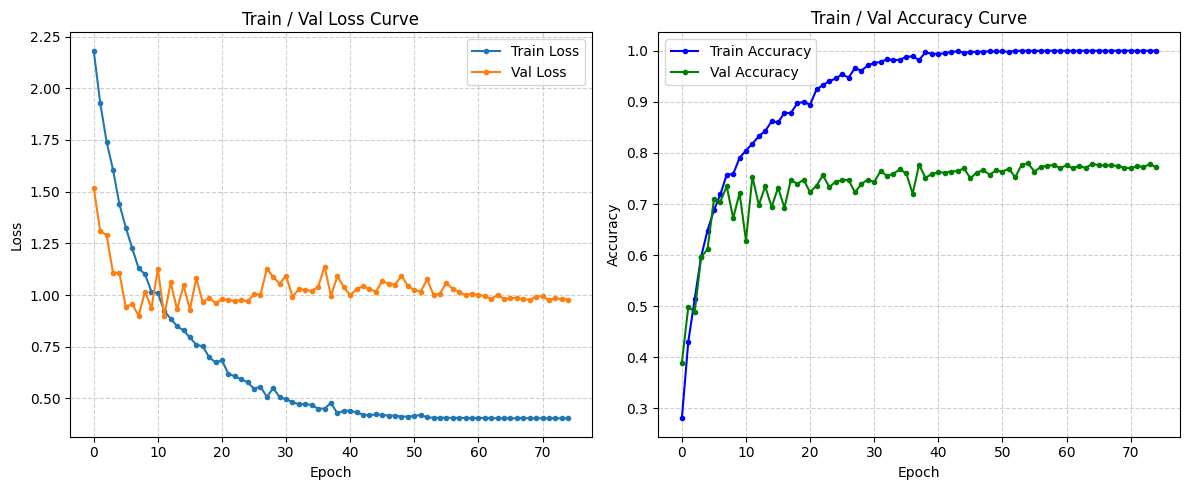

In [15]:
plt.figure(figsize=(12, 5))

# 绘制 Loss 曲线
plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss", marker='o', markersize=3)
plt.plot(val_losses, label="Val Loss", marker='o', markersize=3)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train / Val Loss Curve")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# 绘制 Accuracy 曲线
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label="Train Accuracy", marker='o', markersize=3, color='blue')
plt.plot(val_accuracies, label="Val Accuracy", marker='o', markersize=3, color='green')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train / Val Accuracy Curve")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

## 7) 测试集推理与结果生成
执行测试推理前，将回载上面跑出来的“最佳验证集权重”，以此来产出最终提交的结果。

In [16]:
os.makedirs("final_result", exist_ok=True)
# -------------------------
# 加载最佳模型权重
# -------------------------
# 方式 1 ：使用训练过程中保存的最佳模型路径
model_path = best_model_path
# 方式 2 ：手动指定 model_checkpoints 文件夹下的模型路径
# model_path = "model_checkpoints/CHINESE_best_model_acc51.50.pth"

print(f"Loading best model from {model_path} for testing...")
model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))

model.eval()

output_path = f'final_result/{DATA_NAME}.txt'
all_test_labels = []

with torch.no_grad():
    for test_data in test_loader:  # test_loader 已经是 shuffle=False
        test_data = test_data.to(device)
        test_output = model(test_data)
        test_pred = torch.argmax(test_output, dim=1)
        all_test_labels.extend(test_pred.cpu().tolist())

# 保存 test 预测标签（每行一个数字）
with open(output_path, "w", encoding="utf-8") as f:
    for label in all_test_labels:
        f.write(f"{int(label)}\n")

print(f"Saved {len(all_test_labels)} labels to: {output_path}")

Loading best model from model_checkpoints/SLEEP_best_model_acc77.95.pth for testing...
Saved 1945 labels to: final_result/SLEEP.txt
